In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    TextVectorization,
    Embedding,
    Conv1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)

from sklearn.metrics import (
    precision_recall_fscore_support,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

tf.keras.utils.set_random_seed(42)

In [2]:
olid_train = pd.read_csv("data/olid-train-small.csv")
olid_test = pd.read_csv("data/olid-test.csv")
hasoc_train = pd.read_csv("data/hasoc-train.csv")

print("OLID train:", olid_train.shape)
print("OLID test:", olid_test.shape)
print("HASOC train:", hasoc_train.shape)

OLID train: (5852, 3)
OLID test: (860, 3)
HASOC train: (5852, 3)


In [3]:
def run_cnn(train_df, test_df, experiment_name):

    X_train = train_df["text"].astype(str).values
    y_train = train_df["labels"].values

    X_test = test_df["text"].astype(str).values
    y_test = test_df["labels"].values

    vectorizer = TextVectorization(
        max_tokens=20000,
        output_sequence_length=100
    )

    vectorizer.adapt(X_train)

    model = Sequential([
        vectorizer,
        Embedding(20000, 128),
        Conv1D(128, 5, activation="relu"),
        GlobalMaxPooling1D(),
        Dropout(0.5),
        Dense(64, activation="relu"),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    model.fit(
        X_train,
        y_train,
        epochs=5,
        batch_size=32,
        validation_split=0.1,
        verbose=1
    )

    probabilities = model.predict(X_test, verbose=0).flatten()
    predictions = (probabilities >= 0.5).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test,
        predictions,
        labels=[0, 1],
        zero_division=0
    )

    macro_precision, macro_recall, macro_f1, _ = (
        precision_recall_fscore_support(
            y_test,
            predictions,
            average="macro",
            zero_division=0
        )
    )

    accuracy = accuracy_score(y_test, predictions)

    cm = confusion_matrix(
        y_test,
        predictions,
        labels=[0, 1]
    )

    results = test_df.copy()
    results["prediction"] = predictions

    metrics = {
        "Experiment": experiment_name,
        "NOT Precision": precision[0],
        "NOT Recall": recall[0],
        "NOT F1": f1[0],
        "OFF Precision": precision[1],
        "OFF Recall": recall[1],
        "OFF F1": f1[1],
        "Macro Precision": macro_precision,
        "Macro Recall": macro_recall,
        "Macro F1": macro_f1,
        "Accuracy": accuracy
    }

    return model, results, metrics, cm

In [4]:
cnn_olid, cnn_olid_results, cnn_olid_metrics, cnn_cm_olid = run_cnn(
    olid_train,
    olid_test,
    "In-domain: OLID → OLID"
)

cnn_hasoc, cnn_hasoc_results, cnn_hasoc_metrics, cnn_cm_hasoc = run_cnn(
    hasoc_train,
    olid_test,
    "Cross-domain: HASOC → OLID"
)

Epoch 1/5
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6016 - loss: 0.6706 - val_accuracy: 0.6212 - val_loss: 0.6444
Epoch 2/5
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.7161 - loss: 0.5630 - val_accuracy: 0.7235 - val_loss: 0.5439
Epoch 3/5
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.8578 - loss: 0.3395 - val_accuracy: 0.7218 - val_loss: 0.6510
Epoch 4/5
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9421 - loss: 0.1631 - val_accuracy: 0.7065 - val_loss: 0.8144
Epoch 5/5
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.9765 - loss: 0.0787 - val_accuracy: 0.6621 - val_loss: 1.0786
Epoch 1/5
165/165 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.6567 - loss: 0.6413 - val_accuracy: 0.2338 - val_loss: 0.8958
Epoch 2/5
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.7034 - loss: 0.5694 - val_accuracy: 0.4437 - val_loss: 0.8663
Epoch 3/5
165/165 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.8333 - loss: 0.3821 - val_accuracy: 0.

In [5]:
cnn_comparison = pd.DataFrame([
    cnn_olid_metrics,
    cnn_hasoc_metrics
])

cnn_comparison.round(4)

,Experiment,NOT Precision,NOT Recall,NOT F1,OFF Precision,OFF Recall,OFF F1,Macro Precision,Macro Recall,Macro F1,Accuracy
0,In-domain: OLID → OLID,0.8608,0.6484,0.7397,0.4453,0.7292,0.5529,0.6531,0.6888,0.6463,0.6709
1,Cross-domain: HASOC → OLID,0.7721,0.8306,0.8003,0.4560,0.3667,0.4065,0.6140,0.5987,0.6034,0.7012


In [6]:
cnn_drop = (
    cnn_olid_metrics["Macro F1"]
    - cnn_hasoc_metrics["Macro F1"]
)

cnn_relative_drop = (
    cnn_drop / cnn_olid_metrics["Macro F1"]
) * 100

print(f"In-domain Macro F1:   {cnn_olid_metrics['Macro F1']:.4f}")
print(f"Cross-domain Macro F1: {cnn_hasoc_metrics['Macro F1']:.4f}")
print(f"Absolute drop:         {cnn_drop:.4f}")
print(f"Relative drop:         {cnn_relative_drop:.2f}%")

In-domain Macro F1:   0.6463
Cross-domain Macro F1: 0.6034
Absolute drop:         0.0429
Relative drop:         6.64%


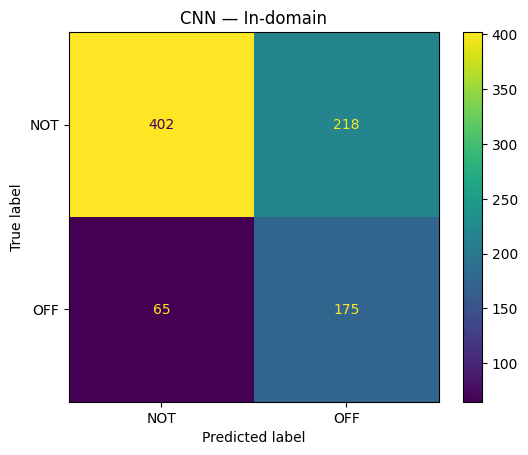

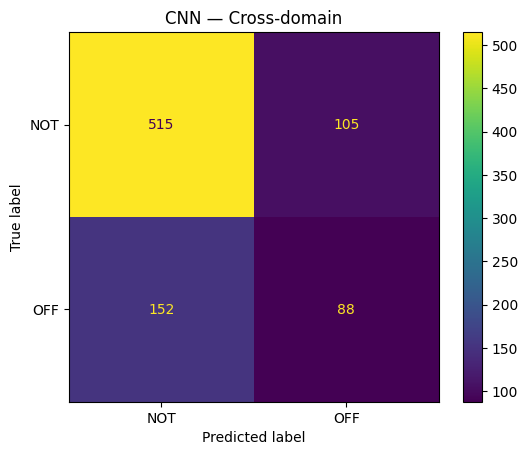

In [7]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cnn_cm_olid,
    display_labels=["NOT", "OFF"]
)

disp.plot()
plt.title("CNN — In-domain")
plt.show()


disp = ConfusionMatrixDisplay(
    confusion_matrix=cnn_cm_hasoc,
    display_labels=["NOT", "OFF"]
)

disp.plot()
plt.title("CNN — Cross-domain")
plt.show()

In [8]:
def error_counts(results):

    false_positives = results[
        (results["labels"] == 0) &
        (results["prediction"] == 1)
    ]

    false_negatives = results[
        (results["labels"] == 1) &
        (results["prediction"] == 0)
    ]

    return len(false_positives), len(false_negatives)


olid_fp, olid_fn = error_counts(cnn_olid_results)
hasoc_fp, hasoc_fn = error_counts(cnn_hasoc_results)

print("IN-DOMAIN")
print("False positives:", olid_fp)
print("False negatives:", olid_fn)

print("\nCROSS-DOMAIN")
print("False positives:", hasoc_fp)
print("False negatives:", hasoc_fn)

IN-DOMAIN
False positives: 218
False negatives: 65

CROSS-DOMAIN
False positives: 105
False negatives: 152
